In [ ]:
scenario = "1"
import yaml
import plotter.style as style
config_file = f"./experiments/scenarios/{scenario}.yaml"
with open(config_file, "r") as f:
    config = yaml.safe_load(f)
    seeds = config["seeds"] #if args.seed == -1 else [args.seed]
    workload = config["workloads"][0]  # Assuming we want to run the first workload
    provider = config["provider"]
    maes = config["mae_forecast"] #if args.mae == -1 else [args.mae]
    periods = config["periods"]

import plotter.plotter as plotter
path = f"./experiments/plots/{provider}"

import os 
if not os.path.exists(path):
    os.makedirs(path)

In [ ]:
!python postprocessing/summarize.py --scenario 1

In [4]:
import pandas as pd
provider = "aws"
summary_df_ = pd.read_csv(
    f"experiments/out/{provider}/summary.csv",
    header=[0, 1],
    index_col=[0, 1, 2]
)

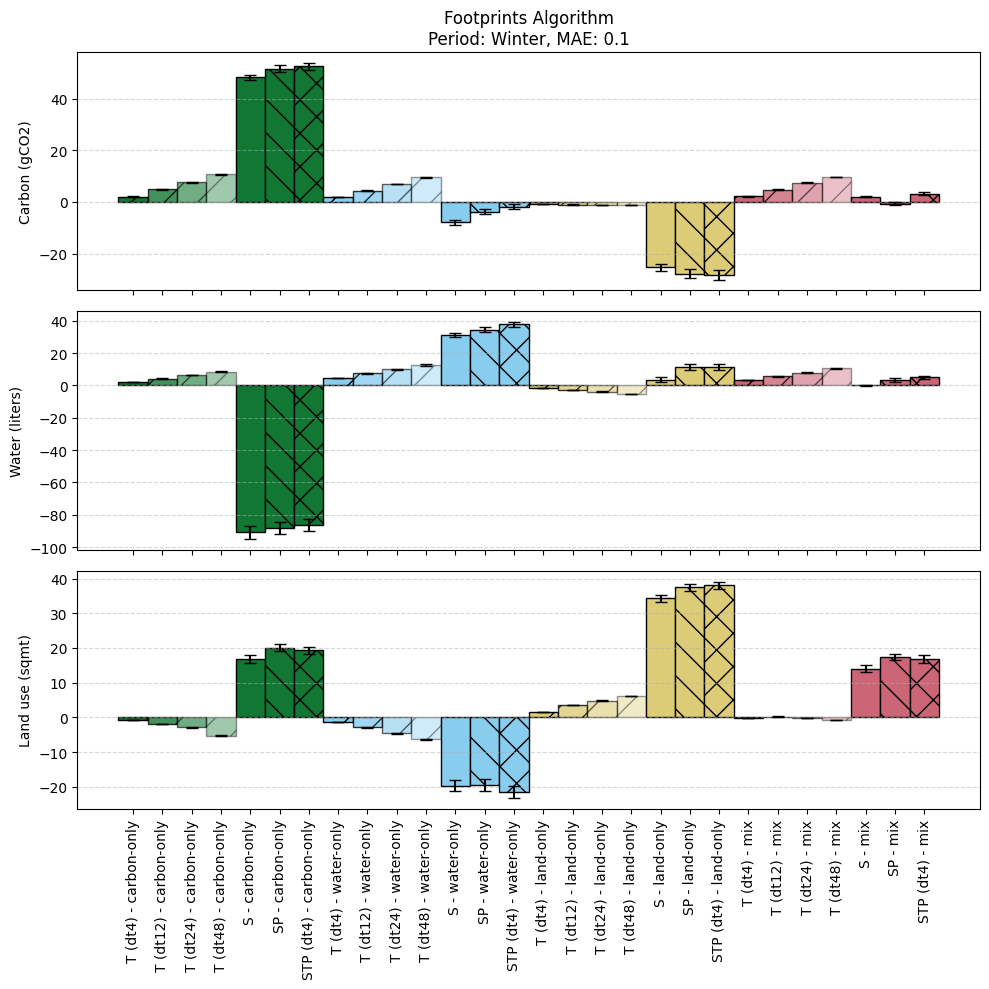

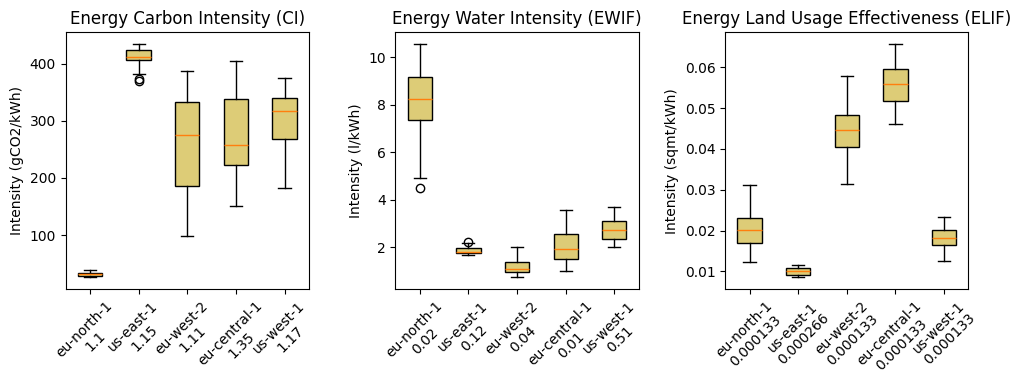

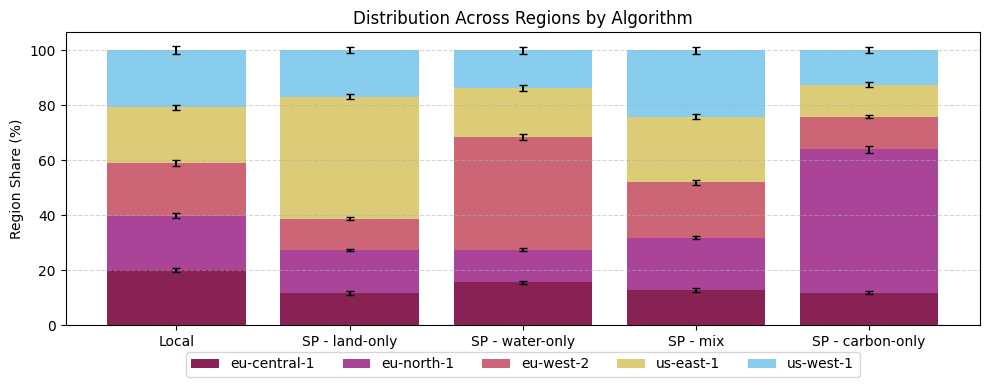

In [ ]:
plotter.plot_all_algo_all_factors(summary_df_, 0.1, "winter", "./experiments/plots/aws", improvement=True)
plotter.plot_intensity_boxplots(providers = ["aws"], mae=0.1, period=periods["winter"], period_name="winter")
plotter.region_load_distribution_plot(summary_df_, "./experiments/plots/aws", "aws")

In [ ]:
mae = 0.1
period_name = "winter"

In [ ]:
factor = "land_use"
suffix = ""

In [ ]:
100 * summary_df_.loc[(slice(None), mae, period_name), (f"migration_{factor}_footprint_actual{suffix}", "mean")] / summary_df_.loc[(slice(None), mae, period_name), (f"tot_{factor}_footprint_actual{suffix}", "mean")]

In [ ]:
# Define the subset of algorithms to compare
subset_algorithms = [
            "TP_[1.0, 0.0, 0.0]_dt4", #"TP_[1.0, 0.0, 0.0]_dt12", "TP_[1.0, 0.0, 0.0]_dt24", "TP_[1.0, 0.0, 0.0]_dt48", "R_[1.0, 0.0, 0.0]", 
            "RP_[1.0, 0.0, 0.0]", "TRP_[1.0, 0.0, 0.0]_dt4",
            "TP_[0.0, 1.0, 0.0]_dt4", #"TP_[0.0, 1.0, 0.0]_dt12", "TP_[0.0, 1.0, 0.0]_dt24", "TP_[0.0, 1.0, 0.0]_dt48", "R_[0.0, 1.0, 0.0]",
            "RP_[0.0, 1.0, 0.0]", "TRP_[0.0, 1.0, 0.0]_dt4",
            "TP_[0.0, 0.0, 1.0]_dt4", #"TP_[0.0, 0.0, 1.0]_dt12", "TP_[0.0, 0.0, 1.0]_dt24", "TP_[0.0, 0.0, 1.0]_dt48", "R_[0.0, 0.0, 1.0]", 
            "RP_[0.0, 0.0, 1.0]", "TRP_[0.0, 0.0, 1.0]_dt4",
            "TP_[0.333, 0.333, 0.334]_dt4", #"TP_[0.333, 0.333, 0.334]_dt12", "TP_[0.333, 0.333, 0.334]_dt24", "TP_[0.333, 0.333, 0.334]_dt48", "R_[0.333, 0.333, 0.334]", 
            "RP_[0.333, 0.333, 0.334]", "TRP_[0.333, 0.333, 0.334]_dt4"
        ]

# Select relevant columns for the table
columns = [
    #("tot_carbon_footprint_actual", "mean"),
    #("tot_carbon_footprint_actual", "std"),
    ("tot_carbon_footprint_actual_improvement", "mean"),
    ("tot_carbon_footprint_actual_improvement", "std"),
    #("tot_water_footprint_actual", "mean"),
    #("tot_water_footprint_actual", "std"),
    ("tot_water_footprint_actual_improvement", "mean"),
    ("tot_water_footprint_actual_improvement", "std"),
    #("tot_land_use_footprint_actual", "mean"),
    #("tot_land_use_footprint_actual", "std"),
    ("tot_land_use_footprint_actual_improvement", "mean"),
    ("tot_land_use_footprint_actual_improvement", "std")

]

# Filter the summary_df_ for the subset of algorithms and all periods, for a fixed mae (e.g., 0.1)
mae_value = 0.1
latex_df = summary_df_.loc[(subset_algorithms, mae_value, slice(None)), columns]

# Reset index for better formatting
latex_df = latex_df.reset_index()

# Rename columns for LaTeX clarity
latex_df = latex_df.drop(columns=["mae"])
latex_df["algorithm"] =  latex_df["algorithm"].apply(lambda algo: style.style[algo]["name"])
latex_df = latex_df.rename(columns={
    "tot_carbon_footprint_actual_improvement": "carbon improvement",
    "tot_water_footprint_actual_improvement": "water improvement",
    "tot_land_use_footprint_actual_improvement": "land use improvement"
    })


print(latex_df.groupby(["algorithm","period"]).first().to_latex(index=True, float_format="%.2f"))


In [ ]:
period = "winter"
latex_df_mae = summary_df_.loc[(subset_algorithms, slice(None), period), columns]

# Reset index for better formatting
latex_df_mae = latex_df_mae.reset_index()

# Rename columns for LaTeX clarity
latex_df_mae = latex_df_mae.drop(columns=["period"])
latex_df_mae["algorithm"] =  latex_df_mae["algorithm"].apply(lambda algo: style.style[algo]["name"])
latex_df_mae = latex_df_mae.rename(columns={
    "tot_carbon_footprint_actual_improvement": "carbon improvement",
    "tot_water_footprint_actual_improvement": "water improvement",
    "tot_land_use_footprint_actual_improvement": "land use improvement"
    })

print(latex_df_mae.groupby(["algorithm","mae"]).first().to_latex(index=True, float_format="%.2f"))

In [ ]:
import matplotlib.pyplot as plt

# Define factors and columns
factors = [
    ("Carbon", "tot_carbon_footprint_actual_improvement"),
    ("Water", "tot_water_footprint_actual_improvement"),
    ("Land Use", "tot_land_use_footprint_actual_improvement")
]

subset_algorithms = [
    "TP_[1.0, 0.0, 0.0]_dt4", "RP_[1.0, 0.0, 0.0]", "TRP_[1.0, 0.0, 0.0]_dt4",
    "TP_[0.0, 1.0, 0.0]_dt4", "RP_[0.0, 1.0, 0.0]", "TRP_[0.0, 1.0, 0.0]_dt4",
    "TP_[0.0, 0.0, 1.0]_dt4", "RP_[0.0, 0.0, 1.0]", "TRP_[0.0, 0.0, 1.0]_dt4",
    "TP_[0.333, 0.333, 0.334]_dt4", "RP_[0.333, 0.333, 0.334]", "TRP_[0.333, 0.333, 0.334]_dt4"
]
mae_value = 0.1

periods = summary_df_.index.get_level_values("period").unique()
algorithms = [algo for algo in subset_algorithms]

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)


period_labels = [str(period).capitalize() for period in periods]

for idx, (factor_name, col_prefix) in enumerate(factors):
    ax = axes[idx]
    bar_width = 0.9 / len(algorithms)
    for i, algo in enumerate(algorithms):
        means = summary_df_.loc[(algo, mae_value, periods), (col_prefix, "mean")].values
        stds = summary_df_.loc[(algo, mae_value, periods), (col_prefix, "std")].values
        ax.bar(
            [p + i * bar_width for p in range(len(periods))],
            means,
            yerr=stds,
            width=bar_width,
            label=style.style[algo]["name"],
            color=style.style[algo]["color"],
            hatch=style.style[algo]["hatch"],
            alpha=style.style[algo]["alpha"],
            edgecolor="black"
        )
        # Set x-ticks in the middle of grouped bars for each period
        ax.set_xticks([p + bar_width * (len(algorithms) / 2 - 0.5) for p in range(len(periods))])
    #ax.set_xticks(range(len(periods)))
    ax.set_xticklabels(period_labels, rotation=0)
    ax.set_ylabel(f"{factor_name}\nImprovement (%)")
    #ax.set_title(f"{factor_name} Footprint Improvement")
    ax.grid(axis='y', linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, title="Algorithm", loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.15)
)
plt.tight_layout()
plt.show()
